<a href="https://colab.research.google.com/github/aryan2107-cloud/100-Day-ML-Challenge-/blob/main/Day39_Modelling%26Tuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import time

from sklearn.model_selection import cross_val_score, StratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier, StackingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report,
                             roc_curve, precision_recall_curve, average_precision_score)

import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')


In [2]:
!pip install xgboost lightgbm imbalanced-learn optuna -q
import xgboost as xgb
import lightgbm as lgb
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 7.2 MB/s eta 0:00:00


In [3]:
from google.colab import drive
drive.mount('/content/drive')

# After mounting, you can verify your files. For example, if your file is in 'colab_data' folder:
# !ls /content/drive/MyDrive/colab_data

Mounted at /content/drive


In [4]:
with open('/content/drive/MyDrive/processed_data.pkl', 'rb') as f:
  data = pickle.load(f)
  x_train = data['x_train']
  x_test = data['x_test']
  y_train = data['y_train']
  y_test = data['y_test']
  feature_names = data['feature_names']
  print("Loaded processed data")

Loaded processed data


In [5]:
print(f"\nTrain: {x_train.shape[0]:,} | Test: {x_test.shape[0]:,}")
print(f"Features: {x_train.shape[1]}")
print(f"Default rate: {y_train.mean()*100:.2f}%")


Train: 24,000 | Test: 6,000
Features: 39
Default rate: 22.12%


In [6]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)
print("Features scaled")

Features scaled


In [7]:
#Baseline model comparison
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(max_depth=10, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42),
    'Gradient Boosing': GradientBoostingClassifier(n_estimators=100, max_depth=5, random_state=42),
    'XGBoost': xgb.XGBClassifier(n_estimators=100, max_depth=5, random_state=42, verbosity=0, n_jobs=-1),
    'LightGBM': lgb.LGBMClassifier(n_estimators=100, max_depth=5, random_state=42, verbose=-1, n_jobs=-1),
    'KNN': KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
}

print(f"Comparing {len(models)} models. . . ")

Comparing 7 models. . . 


In [8]:
results = []

for name, model in models.items():
  start = time.time()
  model.fit(x_train_scaled, y_train)
  train_time = time.time() - start

  y_pred = model.predict(x_test_scaled)
  y_prob = model.predict_proba(x_test_scaled)[:, 1] if hasattr(model, 'predict_proba') else None

  result = {
      'Model': name,
      'Accuracy': accuracy_score(y_test, y_pred),
      'precision': precision_score(y_test, y_pred),
      'Recall': recall_score(y_test, y_pred),
      'F1 score': f1_score(y_test, y_pred),
      'ROC-AUC': roc_auc_score(y_test, y_prob) if y_prob is not None else np.nan,
      'Time': train_time
  }
  results.append(result)

  print(f"{name:<22} F1: {result['F1 score']:.4f} Recall: {result['Recall']} AUC: {result['ROC-AUC']:.4f}")

results_df = pd.DataFrame(results).sort_values('F1 score', ascending=False)
print(f"Best by F1: {results_df.iloc[0]['Model']}")

Logistic Regression    F1: 0.3918 Recall: 0.2803315749811605 AUC: 0.7508
Decision Tree          F1: 0.4451 Recall: 0.3556895252449133 AUC: 0.7270
Random Forest          F1: 0.4603 Recall: 0.3541823662396383 AUC: 0.7754
Gradient Boosing       F1: 0.4618 Recall: 0.359457422758101 AUC: 0.7809
XGBoost                F1: 0.4650 Recall: 0.3654860587792012 AUC: 0.7692
LightGBM               F1: 0.4709 Recall: 0.3624717407686511 AUC: 0.7785
KNN                    F1: 0.4124 Recall: 0.3300678221552374 AUC: 0.7007
Best by F1: LightGBM


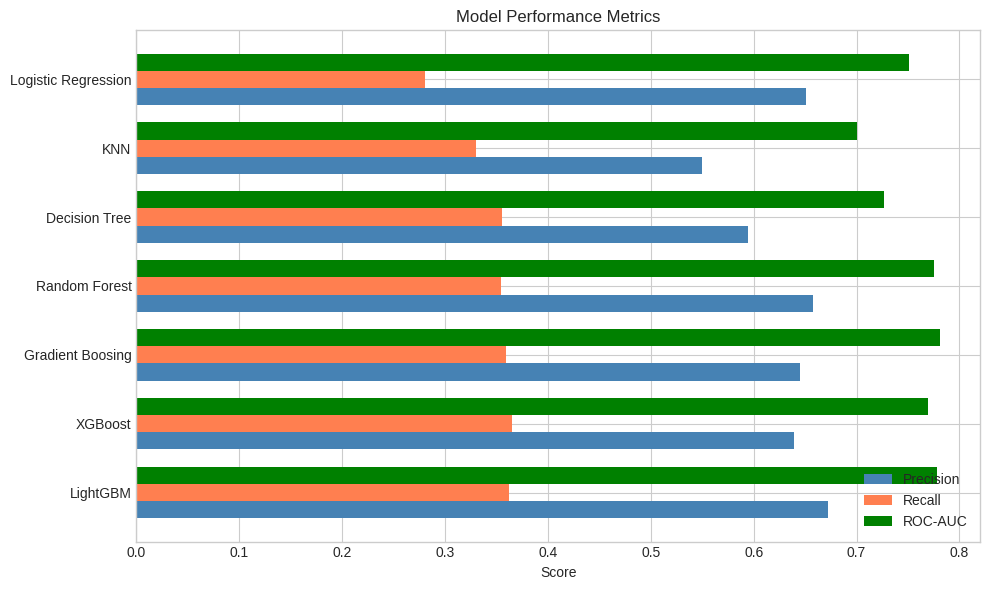

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(results_df))
width =  0.25

ax.barh(x - width, results_df['precision'], width, label='Precision', color='steelblue')
ax.barh(x, results_df['Recall'], width, label='Recall', color='coral')
ax.barh(x + width, results_df['ROC-AUC'], width, label='ROC-AUC', color='green')

ax.set_yticks(x)
ax.set_yticklabels(results_df['Model'])
ax.set_xlabel('Score')
ax.set_title('Model Performance Metrics')
ax.legend(loc='lower right')

plt.tight_layout()
plt.show()

Handling class imbalance

In [10]:
print("MEthod 1: Class Weights")

rf_weighted = RandomForestClassifier(n_estimators=100, max_depth=10, class_weight='balanced',
                                     random_state=42, n_jobs=-1)

rf_weighted.fit(x_train_scaled, y_train)

y_pred_w = rf_weighted.predict(x_test_scaled)
y_prob_w = rf_weighted.predict_proba(x_test_scaled)[:, 1]

print(f"Accuracy: {accuracy_score(y_test, y_pred_w)}")
print(f"Precision: {precision_score(y_test, y_pred_w)}")
print(f"recall: {recall_score(y_test, y_pred_w)}")
print(f"F1 score: {f1_score(y_test, y_pred_w)}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_w)}")

MEthod 1: Class Weights
Accuracy: 0.7851666666666667
Precision: 0.5130315500685871
recall: 0.5636774679728711
F1 score: 0.5371633752244165
ROC-AUC: 0.7749879012835041


In [11]:
#Method 2: SMOTE
smote = SMOTE(random_state=42)
x_train_smote, y_train_smote = smote.fit_resample(x_train_scaled, y_train)

print(f"Before SMOTE: {len(x_train_scaled):,}")
print(f"After SMOTE: {len(x_train_smote):,}")

rf_smote = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_smote.fit(x_train_smote, y_train_smote)

y_pred_s = rf_smote.predict(x_test_scaled)
y_prob_s = rf_smote.predict_proba(x_test_scaled)[:, 1]

print(f"Accuracy: {accuracy_score(y_test, y_pred_s)}")
print(f"Precision: {precision_score(y_test, y_pred_s)}")
print(f"recall: {recall_score(y_test, y_pred_s)}")
print(f"F1 score: {f1_score(y_test, y_pred_s)}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_s)}")

Before SMOTE: 24,000
After SMOTE: 37,382
Accuracy: 0.7878333333333334
Precision: 0.5188811188811189
recall: 0.5591559909570459
F1 score: 0.538266231410954
ROC-AUC: 0.773002760329627


In [13]:
imbalance_results = [
    {'Method': 'No handling', 'F1': results_df[results_df['Model'] == 'Random Forest']['F1 score'].values[0],
     'Recall': results_df[results_df['Model'] == 'Random Forest']['Recall'].values[0]},
    {'Method': 'Class weights', 'F1': f1_score(y_test, y_pred_w), 'Recall': recall_score(y_test, y_pred_w)},
    {'Method': 'SMOTE', 'F1': f1_score(y_test, y_pred_s), 'Recall': recall_score(y_test, y_pred_s)}
]

imb_df = pd.DataFrame(imbalance_results)
print("\nImbalance Handling Comparison:")
print(imb_df.round(4))


Imbalance Handling Comparison:
          Method      F1  Recall
0    No handling  0.4603  0.3542
1  Class weights  0.5372  0.5637
2          SMOTE  0.5383  0.5592


Hyperparameter Tuning with Optuna

In [15]:
def xgb_objective(trial):
  params = {
      'n_estimators': trial.suggest_int('n_estimators', 50, 300),
      'max_depth': trial.suggest_int('max_depth', 3, 10),
      'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
      'subsample': trial.suggest_float('subsample', 0.5, 1.0),
      'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
      'scale_pos_weight': trial.suggest_float('scale_pos_weight', 1, 10),
      'random_state': 42,
      'n_jobs': -1
  }
  model = xgb.XGBClassifier(**params)
  scores = cross_val_score(model, x_train_scaled, y_train, cv=5, scoring='f1', n_jobs=-1)
  return scores.mean()

print('Tuning XGBoost. . .')
study_xgb = optuna.create_study(direction='maximize')
study_xgb.optimize(xgb_objective, n_trials=50, show_progress_bar=True)

print(f"Best F1: {study_xgb.best_value:.4f}")
print(f"Best params: {study_xgb.best_params}")

Tuning XGBoost. . .


  0%|          | 0/50 [00:00<?, ?it/s]

Best F1: 0.5463
Best params: {'n_estimators': 106, 'max_depth': 6, 'learning_rate': 0.029636899904610492, 'subsample': 0.5501243591929447, 'colsample_bytree': 0.9698830177264336, 'scale_pos_weight': 2.9035056496711382}


In [17]:
#Training the best XGBoost
best_xgb = xgb.XGBClassifier(**study_xgb.best_params, random_state=42, verbosity=0, n_jobs=-1)
best_xgb.fit(x_train_scaled, y_train)

y_pred_xgb = best_xgb.predict(x_test_scaled)
y_prob_xgb = best_xgb.predict_proba(x_test_scaled)[:, 1]

print("Tuned XGBoost results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb)}")
print(f"Precision: {precision_score(y_test, y_pred_xgb)}")
print(f"Recall: {recall_score(y_test, y_pred_xgb)}")
print(f"F1 score: {f1_score(y_test, y_pred_xgb)}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_xgb)}")

Tuned XGBoost results:
Accuracy: 0.7865
Precision: 0.5155615696887687
Recall: 0.5742275810097965
F1 score: 0.5433155080213904
ROC-AUC: 0.7801723282961928


In [20]:
#Optuna for LightBGM
def lgb_objective(trial):
  params = {
      'n_estimators': trial.suggest_int('n_estimators', 50, 300),
      'max_depth': trial.suggest_int('max_depth', 3, 10),
      'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
      'subsample': trial.suggest_float('subsample', 0.6, 1.0),
      'num_leaves': trial.suggest_int('num_leaves', 20, 100),
      'colsample_byTree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
      'class_weight': 'balanced',
      'random_state': 42,
      'verbose': -1,
      'n_jobs': -1
  }

  model = lgb.LGBMClassifier(**params)
  scores = cross_val_score(model, x_train_scaled, y_train, cv=3, scoring='f1', n_jobs=-1)
  return scores.mean()

print("Tuning LightBGM with optuna (50 trials). . .")
study_lgb = optuna.create_study(direction='maximize')
study_lgb.optimize(lgb_objective, n_trials=50, show_progress_bar=True)

print(f"Best F1: {study_lgb.best_value:.4f}")
print(f"Best params: {study_lgb.best_params}")

Tuning LightBGM with optuna (50 trials). . .


  0%|          | 0/50 [00:00<?, ?it/s]

Best F1: 0.5436
Best params: {'n_estimators': 100, 'max_depth': 4, 'learning_rate': 0.034602491832715715, 'subsample': 0.8307771002505374, 'num_leaves': 32, 'colsample_bytree': 0.9231402393595214}


Ensemble methods

In [23]:
voting = VotingClassifier(
    estimators=[
        ('lr', LogisticRegression(random_state=42, max_iter=1000)),
        ('rf', RandomForestClassifier(n_estimators=100, max_depth=10, class_weight='balanced', random_state=42, n_jobs=-1)),
        ('xgb', xgb.XGBClassifier(**study_xgb.best_params, random_state=42, verbosity=0, n_jobs=-1)),
        ('lgb', lgb.LGBMClassifier(**study_lgb.best_params, random_state=42, class_weight='balanced', verbose=-1, n_jobs=-1))
    ],
    voting='soft'
)

print("Training Voting Classifier. . .")
voting.fit(x_train_scaled, y_train)

y_pred_vote = voting.predict(x_test_scaled)
y_prob_vote = voting.predict_proba(x_test_scaled)[:, 1]

print("results: ")
print(f"Accuracy: {accuracy_score(y_test, y_pred_vote)}")
print(f"Precision: {precision_score(y_test, y_pred_vote)}")
print(f"Recall: {recall_score(y_test, y_pred_vote)}")
print(f"F1 score: {f1_score(y_test, y_pred_vote)}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_vote)}")

Training Voting Classifier. . .
results: 
Accuracy: 0.8021666666666667
Precision: 0.5558213716108453
Recall: 0.5252449133383572
F1 score: 0.5401007361487795
ROC-AUC: 0.7789817275112638


In [27]:
#Stacking classsifier
stacking = StackingClassifier(
    estimators=[
        ('lr', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)),
        ('rf', RandomForestClassifier(n_estimators=100, max_depth=10, class_weight='balanced')),
        ('xgb', xgb.XGBClassifier(**study_xgb.best_params, random_state=42, verbosity=0, n_jobs=-1))
    ],
    final_estimator=LogisticRegression(max_iter=1000),
    cv=5,
    n_jobs=-1
)

print("Training Stacking Classifier. . .")
stacking.fit(x_train_scaled, y_train)

y_pred_stack = stacking.predict(x_test_scaled)
y_prob_stack = stacking.predict_proba(x_test_scaled)[:, 1]

print('Results: ')
print(f"Accuracy: {accuracy_score(y_test, y_pred_stack)}")
print(f"Precision: {precision_score(y_test, y_pred_stack)}")
print(f"Recall: {recall_score(y_test, y_pred_stack)}")
print(f"F1 score: {f1_score(y_test, y_pred_stack)}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_stack)}")

Training Stacking Classifier. . .
Results: 
Accuracy: 0.8145
Precision: 0.6334164588528678
Recall: 0.38281838733986434
F1 score: 0.4772193518083607
ROC-AUC: 0.7801178215827557


Threshold Tuning

Best threshold: 0.46


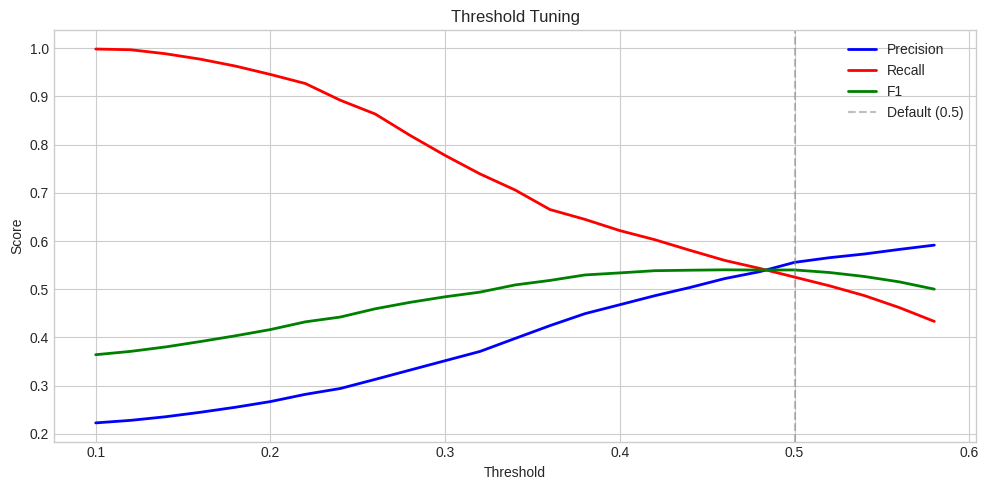

In [31]:
#Finding the optimal thresholds for the best model
best_probs = y_prob_vote

thresholds = np.arange(0.1, 0.6, 0.02)
threshold_results = []

for thresh in thresholds:
  y_pred_t = (best_probs >= thresh).astype(int)
  threshold_results.append({
      'Threshold': thresh,
      'Accuracy': accuracy_score(y_test, y_pred_t),
      'Precision': precision_score(y_test, y_pred_t),
      'Recall': recall_score(y_test, y_pred_t),
      'F1': f1_score(y_test, y_pred_t),
  })

thresh_df = pd.DataFrame(threshold_results)

plt.figure(figsize=(10, 5))
plt.plot(thresh_df['Threshold'], thresh_df['Precision'], 'b-', label='Precision', linewidth=2)
plt.plot(thresh_df['Threshold'], thresh_df['Recall'], 'r-', label='Recall', linewidth=2)
plt.plot(thresh_df['Threshold'], thresh_df['F1'], 'g-', label='F1', linewidth=2)
plt.axvline(x=0.5, color='gray', linestyle='--', alpha=0.5, label='Default (0.5)')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Threshold Tuning')
plt.tight_layout()
plt.legend()

best_thresh = thresh_df.loc[thresh_df['F1'].idxmax(), 'Threshold']
print(f"Best threshold: {best_thresh:.2f}")

In [34]:
#Applying the optimal threshold
y_pred_optimal = (best_probs >= best_thresh).astype(int)

print("Optimal threshold results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_optimal)}")
print(f"Precision: {precision_score(y_test, y_pred_optimal)}")
print(f"Recall: {recall_score(y_test, y_pred_optimal)}")
print(f"F1 score: {f1_score(y_test, y_pred_optimal)}")

Optimal threshold results:
Accuracy: 0.7893333333333333
Precision: 0.5221363316936051
Recall: 0.5599095704596835
F1 score: 0.5403636363636364


In [38]:
# Compiling all results
final_results = [
    {'Model': 'Baseline RF', 'Precision': results_df[results_df['Model'] == 'Random Forest']['precision'].values[0],
     'Recall': results_df[results_df['Model'] == 'Random Forest']['Recall'].values[0],
     'F1': results_df[results_df['Model'] == 'Random Forest']['F1 score'].values[0],
     'ROC-AUC': results_df[results_df['Model'] == 'Random Forest']['ROC-AUC'].values[0]},
    {'Model': 'RF + Class Weights', 'Precision': precision_score(y_test, y_pred_w),
     'Recall': recall_score(y_test, y_pred_w), 'F1': f1_score(y_test, y_pred_w),
     'ROC-AUC': roc_auc_score(y_test, y_prob_w)},
    {'Model': 'Tuned XGBoost', 'Precision': precision_score(y_test, y_pred_xgb),
     'Recall': recall_score(y_test, y_pred_xgb), 'F1': f1_score(y_test, y_pred_xgb),
     'ROC-AUC': roc_auc_score(y_test, y_prob_xgb)},
    {'Model': 'Tuned LightGBM', 'Precision': precision_score(y_test, y_pred_lgb),
     'Recall': recall_score(y_test, y_pred_lgb), 'F1': f1_score(y_test, y_pred_lgb),
     'ROC-AUC': roc_auc_score(y_test, y_prob_lgb)},
    {'Model': 'Voting Ensemble', 'Precision': precision_score(y_test, y_pred_vote),
     'Recall': recall_score(y_test, y_pred_vote), 'F1': f1_score(y_test, y_pred_vote),
     'ROC-AUC': roc_auc_score(y_test, y_prob_vote)},
    {'Model': 'Stacking Ensemble', 'Precision': precision_score(y_test, y_pred_stack),
     'Recall': recall_score(y_test, y_pred_stack), 'F1': f1_score(y_test, y_pred_stack),
     'ROC-AUC': roc_auc_score(y_test, y_prob_stack)},
    {'Model': 'Voting + Threshold', 'Precision': precision_score(y_test, y_pred_optimal),
     'Recall': recall_score(y_test, y_pred_optimal), 'F1': f1_score(y_test, y_pred_optimal),
     'ROC-AUC': roc_auc_score(y_test, y_prob_vote)}
]

final_df = pd.DataFrame(final_results).sort_values('F1', ascending=False)

In [39]:
print("Final Model Comparison:")
print(final_df.round(4).to_string(index=False))

Final Model Comparison:
             Model  Precision  Recall     F1  ROC-AUC
     Tuned XGBoost     0.5156  0.5742 0.5433   0.7802
Voting + Threshold     0.5221  0.5599 0.5404   0.7790
   Voting Ensemble     0.5558  0.5252 0.5401   0.7790
RF + Class Weights     0.5130  0.5637 0.5372   0.7750
 Stacking Ensemble     0.6334  0.3828 0.4772   0.7801
       Baseline RF     0.6573  0.3542 0.4603   0.7754
    Tuned LightGBM     0.6799  0.3474 0.4599   0.7803


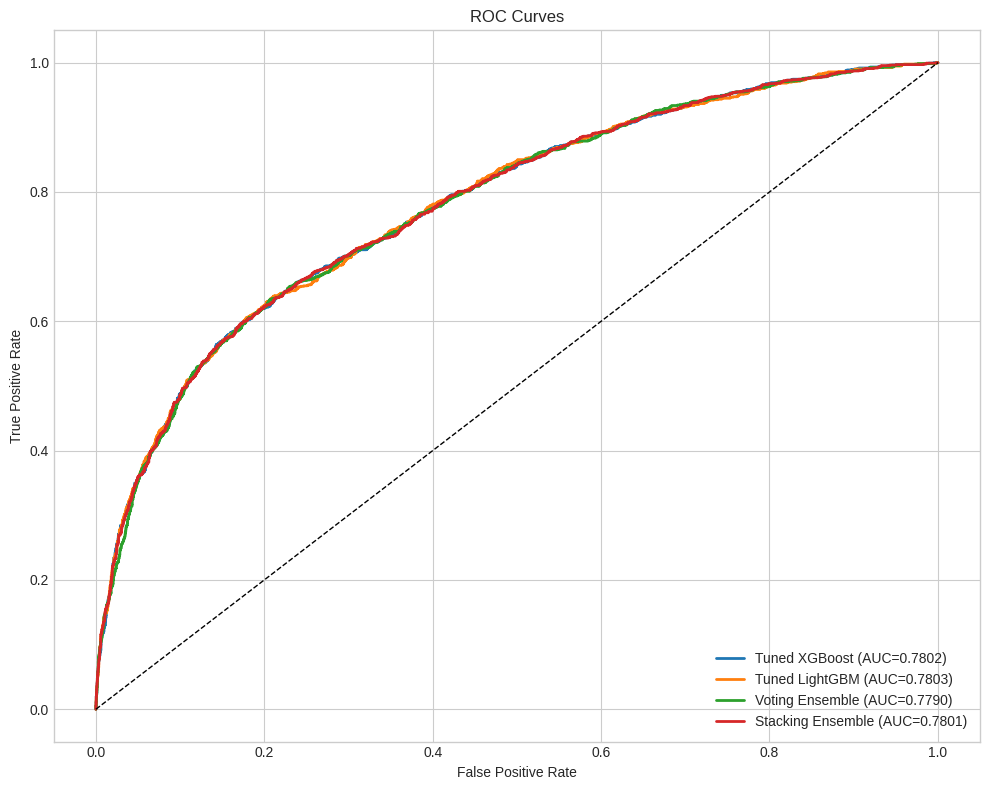

In [40]:
# ROC Curves
plt.figure(figsize=(10, 8))

models_to_plot = [
    ('Tuned XGBoost', y_prob_xgb),
    ('Tuned LightGBM', y_prob_lgb),
    ('Voting Ensemble', y_prob_vote),
    ('Stacking Ensemble', y_prob_stack)
]

for name, probs in models_to_plot:
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    plt.plot(fpr, tpr, linewidth=2, label=f'{name} (AUC={auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [41]:
# Save best model and components
import joblib

best_model = voting
best_threshold = best_thresh

model_artifacts = {
    'model': best_model,
    'scaler': scaler,
    'threshold': best_threshold,
    'feature_names': feature_names if 'feature_names' in dir() else X_train.columns.tolist(),
    'xgb_params': study_xgb.best_params,
    'lgb_params': study_lgb.best_params
}

joblib.dump(model_artifacts, 'model_artifacts.joblib')
print("Model artifacts saved to 'model_artifacts.joblib'")
print(f"\nBest model: Voting Ensemble")
print(f"Optimal threshold: {best_threshold:.2f}")

Model artifacts saved to 'model_artifacts.joblib'

Best model: Voting Ensemble
Optimal threshold: 0.46


In [42]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [43]:
import os
import shutil

path = '/content/drive/MyDrive/loan-default-prediction'
os.makedirs(path, exist_ok=True)

shutil.copy('model_artifacts.joblib', f'{path}/model_artifacts.joblib')
print(f'Saved to: {path}')

Saved to: /content/drive/MyDrive/loan-default-prediction
